# Implement ObsPy TauP to Calculate Angle of Incidence

This notebook provides a complete, clean workflow from raw earthquake catalog and waveform data to shear-wave splitting analysis results. The workflow follows proper sequencing and includes all necessary quality control measures.

## Workflow Overview

1. **Data Loading & Initial Setup** - Load earthquake catalog and station metadata
2. **Extended Time Window Creation** - Create proper time windows for waveform retrieval
3. **Waveform Data Retrieval** - Download seismic data with extended windows
4. **Quality Control Filters** - P-wave rectilinearity, SNR, and incidence angle filtering
5. **Geometric Calculations** - Back-azimuth and distance calculations
6. **Shear-Wave Splitting Analysis** - Dynamic parameter estimation and SWSPy analysis
7. **Results Processing & Visualization** - Compile and visualize splitting parameters

## Key Improvements
- Extended catalog creation moved to proper early position
- Updated P-wave polarization analysis for true incidence angles
- Integrated SNR calculations with proper S-wave timing
- Clean separation of quality control steps

## 1. Import Requirements

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import obspy
from obspy.core.utcdatetime import UTCDateTime
from obspy.clients.fdsn import Client
import os
import sys
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Add local swspy directory to path (before other imports)
swspy_local_path = os.path.abspath('../swspy')
if swspy_local_path not in sys.path:
    sys.path.insert(0, swspy_local_path)

# Import swspy from local directory
import swspy

# Add scripts directory to path for custom modules
sys.path.append('.')
from seismic_geometry import (calculate_back_azimuth, calculate_epicentral_distance_km)
from get_all_traces import get_station_traces
from splitting_functions import *

# Set up plotting
plt.rcParams['figure.figsize'] = (12, 8)

print("Libraries imported successfully")
print(f"ObsPy version: {obspy.__version__}")
print(f"SWSPy available: {'Yes' if 'swspy' in sys.modules else 'No'}")
print(f"SWSPy location: {swspy.__file__}")

mtspec not available, using ObsPy PPSD method
Libraries imported successfully
ObsPy version: 1.4.2
SWSPy available: Yes
SWSPy location: /Users/mhemmett/Seismology/Axial_Splitting/swspy/swspy/__init__.py


## 2. Raw Data Organization

First, we need to process the raw phase pick data to create a structured catalog where each row represents one event at a single station with both P- and S-wave arrival times.

In [2]:
###################################################################

In [3]:
# Load 2018 earthquake test catalog
catalog = pd.read_csv('2018_eq_catalog.csv')

# Load station information
stations_file = '../data/axial_seamount_stations.csv'
stations_df = pd.read_csv(stations_file)

print(f"Stations in catalog: {catalog['station'].value_counts()}")

Stations in catalog: station
OOAXEC3    188899
OOAXEC1    175768
OOAXEC2    173587
OOAXAS1    115223
OOAXCC1    108044
OOAXAS2     76044
OOAXID1     58449
Name: count, dtype: int64


## 3. Extended Time Window Creation

This step creates extended time windows for waveform retrieval. This is critical for proper analysis and must happen early in the workflow, before any quality control that depends on waveform data.

In [4]:
# Create extended time windows for proper waveform analysis
print("Creating extended time windows for waveform retrieval...")

# Apply extended windowing
extended_catalog = create_extended_catalog(catalog, pre_event_time=4.0, post_event_time=15.0)

print(f"Extended catalog created with {len(extended_catalog)} events")
print(f"Time windows: {extended_catalog['total_duration'].iloc[0]} seconds total")
print(f"Pre-event: {extended_catalog['pre_event_sec'].iloc[0]}s, Post-event: {extended_catalog['post_event_sec'].iloc[0]}s")

# Display sample of extended timing
print("\nSample timing windows:")
sample_cols = ['id', 'datetime', 'starttime', 'endtime', 'total_duration']
display(extended_catalog[sample_cols].head())

Creating extended time windows for waveform retrieval...
Extended catalog created with 896014 events
Time windows: 19.0 seconds total
Pre-event: 4.0s, Post-event: 15.0s

Sample timing windows:


,id,datetime,starttime,endtime,total_duration
0,1024511,2015-01-22T00:00:26.740Z,2015-01-22T00:00:22.740000Z,2015-01-22T00:00:41.740000Z,19.0
1,1024511,2015-01-22T00:00:26.740Z,2015-01-22T00:00:22.740000Z,2015-01-22T00:00:41.740000Z,19.0
2,1024511,2015-01-22T00:00:26.740Z,2015-01-22T00:00:22.740000Z,2015-01-22T00:00:41.740000Z,19.0
3,1024512,2015-01-22T00:08:58.530Z,2015-01-22T00:08:54.530000Z,2015-01-22T00:09:13.530000Z,19.0
4,1024512,2015-01-22T00:08:58.530Z,2015-01-22T00:08:54.530000Z,2015-01-22T00:09:13.530000Z,19.0


In [5]:
# Remove leading 'OO' from station names
extended_catalog['station'] = extended_catalog['station'].str.replace('OO', '', regex=False)

In [6]:
# Keep just the data from station AXAS2
filtered_catalog = extended_catalog[extended_catalog['station'] == 'AXAS2'].copy()

In [7]:
##########################

## 4. Waveform Data Retrieval

This section retrieves seismic waveform data using the extended time windows. We'll load the existing trace data and organize it for processing.

In [8]:
test_catalog = filtered_catalog.head(10)

In [9]:
#########################

In [10]:
# Retrieve waveforms for all events in the test catalog using get_all_traces function
print("Retrieving waveforms for all events in the test catalog...")
waveforms = get_station_traces(test_catalog, 'first_event', 'starttime', 'endtime', 'station')

Retrieving waveforms for all events in the test catalog...
Retrieved data for AXAS2 EHE from 2015-01-22T00:08:54.530000Z to 2015-01-22T00:09:13.530000Z
Retrieved data for AXAS2 EHN from 2015-01-22T00:08:54.530000Z to 2015-01-22T00:09:13.530000Z
Retrieved data for AXAS2 EHZ from 2015-01-22T00:08:54.530000Z to 2015-01-22T00:09:13.530000Z
Retrieved data for AXAS2 EHE from 2015-01-22T00:11:44.820000Z to 2015-01-22T00:12:03.820000Z
Retrieved data for AXAS2 EHN from 2015-01-22T00:11:44.820000Z to 2015-01-22T00:12:03.820000Z
Retrieved data for AXAS2 EHZ from 2015-01-22T00:11:44.820000Z to 2015-01-22T00:12:03.820000Z
Retrieved data for AXAS2 EHE from 2015-01-22T02:02:36.910000Z to 2015-01-22T02:02:55.910000Z
Retrieved data for AXAS2 EHN from 2015-01-22T02:02:36.910000Z to 2015-01-22T02:02:55.910000Z
Retrieved data for AXAS2 EHZ from 2015-01-22T02:02:36.910000Z to 2015-01-22T02:02:55.910000Z
Retrieved data for AXAS2 EHE from 2015-01-22T02:41:48.200000Z to 2015-01-22T02:42:07.200000Z
Retrieved d

In [11]:
# Associate waveforms with events in the catalog
print("Organizing waveforms by events...")
waveform_dict = organize_stream_by_events(waveforms, test_catalog)

Organizing waveforms by events...
Organizing stream data for 10 events...
  Event 1: Found 3 traces for AXAS2 at 2015-01-22T00:08:58.530000Z
  Event 2: Found 3 traces for AXAS2 at 2015-01-22T00:11:48.820000Z
  Event 3: Found 3 traces for AXAS2 at 2015-01-22T02:02:40.910000Z
  Event 4: Found 3 traces for AXAS2 at 2015-01-22T02:41:52.200000Z
  Event 5: Found 3 traces for AXAS2 at 2015-01-22T02:42:34.070000Z
  Event 6: Found 3 traces for AXAS2 at 2015-01-22T02:50:16.030000Z
  Event 7: Found 3 traces for AXAS2 at 2015-01-22T02:59:40.830000Z
  Event 8: Found 3 traces for AXAS2 at 2015-01-22T03:00:46.600000Z
  Event 9: Found 3 traces for AXAS2 at 2015-01-22T03:01:31.700000Z
  Event 10: Found 3 traces for AXAS2 at 2015-01-22T03:21:07.700000Z


In [12]:
# Replace catalog id with index
test_catalog['id'] = test_catalog.index

In [13]:
# Organize waveforms by event ID
print("Organizing waveforms by event ID...")
organized_waveforms = organize_waveform_data(waveform_dict, test_catalog)

Organizing waveforms by event ID...


## 5. Quality Control Pipeline

This section implements comprehensive quality control measures including P-wave rectilinearity analysis, signal-to-noise ratio calculations, and incidence angle filtering.

In [14]:
# Define quality control thresholds
QC_THRESHOLDS = {
    'min_snr': 2.0,           # Minimum S-wave signal-to-noise ratio
    'min_rectilinearity': 0.7, # Minimum P-wave rectilinearity
    'max_incidence': 30.0,     # Maximum incidence angle (degrees)
    'min_magnitude': 0.0,      # Minimum event magnitude
}

print("Quality control functions loaded successfully")
print(f"QC Thresholds: {QC_THRESHOLDS}")

Quality control functions loaded successfully
QC Thresholds: {'min_snr': 2.0, 'min_rectilinearity': 0.7, 'max_incidence': 30.0, 'min_magnitude': 0.0}


In [15]:
# Here we'll use TauP model from ObsPy for incidence angle calculations
from obspy.taup import TauPyModel
model = TauPyModel(model="ak135")

In [16]:
organized_waveforms

{3: {'traces': 3 Trace(s) in Stream:
OO.AXAS2..EHE | 2015-01-22T00:08:54.530000Z - 2015-01-22T00:09:13.530000Z | 200.0 Hz, 3801 samples
OO.AXAS2..EHN | 2015-01-22T00:08:54.530000Z - 2015-01-22T00:09:13.530000Z | 200.0 Hz, 3801 samples
OO.AXAS2..EHZ | 2015-01-22T00:08:54.530000Z - 2015-01-22T00:09:13.530000Z | 200.0 Hz, 3801 samples,
  'origin_time': 2015-01-22T00:08:58.530000Z,
  'datetime': '2015-01-22T00:08:58.530Z',
  'starttime': 2015-01-22T00:08:54.530000Z,
  'endtime': 2015-01-22T00:09:13.530000Z,
  'pre_event_sec': 4.0,
  'post_event_sec': 15.0,
  'magnitude': 0.0,
  'depth': 3.79,
  'latitude': 45.971,
  'longitude': -129.9888,
  'station': 'AXAS2',
  'p_arrival_time': 1.29,
  's_arrival_time': 2.17},
 8: {'traces': 3 Trace(s) in Stream:
OO.AXAS2..EHE | 2015-01-22T00:11:44.820000Z - 2015-01-22T00:12:03.820000Z | 200.0 Hz, 3801 samples
OO.AXAS2..EHN | 2015-01-22T00:11:44.820000Z - 2015-01-22T00:12:03.820000Z | 200.0 Hz, 3801 samples
OO.AXAS2..EHZ | 2015-01-22T00:11:44.820000Z - 

In [17]:
# Calculate quality control metrics for organized waveforms
print("Calculating quality control metrics for organized waveforms...")

# 1. Calculate S-wave SNR
organized_waveforms = calculate_snr_for_organized_waveforms(organized_waveforms)

Calculating quality control metrics for organized waveforms...
Calculating SNR for 10 events in organized_waveforms...

Processing event 3...
  Found 3 traces for this event

  Calculating SNR for E component:
  S-pick time: 2015-01-22T00:09:00.700000Z
  S-P delay: 0.88s
  Found E trace: 2015-01-22T00:08:54.530000Z to 2015-01-22T00:09:13.530000Z
  Noise window: 2015-01-22T00:09:00.300000Z to 2015-01-22T00:09:00.700000Z (0.40s)
  Signal window: 2015-01-22T00:09:00.700000Z to 2015-01-22T00:09:00.900000Z (0.20s)
  Noise data points: 81
  Signal data points: 41
  Noise RMS: 17.843618
  Signal RMS: 49.563223
  SNR: 2.78

  Calculating SNR for N component:
  S-pick time: 2015-01-22T00:09:00.700000Z
  S-P delay: 0.88s
  Found N trace: 2015-01-22T00:08:54.530000Z to 2015-01-22T00:09:13.530000Z
  Noise window: 2015-01-22T00:09:00.300000Z to 2015-01-22T00:09:00.700000Z (0.40s)
  Signal window: 2015-01-22T00:09:00.700000Z to 2015-01-22T00:09:00.900000Z (0.20s)
  Noise data points: 81
  Signal dat

In [18]:
# 2. Calculate geographic back-azimuth, for coordinate rotation later
organized_waveforms = calculate_back_azimuth_for_organized_waveforms(organized_waveforms, stations_df)

Calculating back-azimuth for 10 events...

Processing event 3...
  Station: AXAS2
  Event location: (45.9710, -129.9888)
  Station location: (45.9360, -130.0130)
  Back-azimuth: 25.67°

Processing event 8...
  Station: AXAS2
  Event location: (45.9388, -130.0110)
  Station location: (45.9360, -130.0130)
  Back-azimuth: 26.41°

Processing event 16...
  Station: AXAS2
  Event location: (45.9432, -130.0202)
  Station location: (45.9360, -130.0130)
  Back-azimuth: 325.19°

Processing event 43...
  Station: AXAS2
  Event location: (45.9748, -129.9922)
  Station location: (45.9360, -130.0130)
  Back-azimuth: 20.43°

Processing event 49...
  Station: AXAS2
  Event location: (45.9458, -129.9892)
  Station location: (45.9360, -130.0130)
  Back-azimuth: 59.36°

Processing event 55...
  Station: AXAS2
  Event location: (45.9595, -129.9957)
  Station location: (45.9360, -130.0130)
  Back-azimuth: 27.10°

Processing event 61...
  Station: AXAS2
  Event location: (45.9475, -129.9895)
  Station locat

In [ ]:
from obspy.taup import TauPyModel
from obspy.geodetics import gps2dist_azimuth
def calculate_incidence_angle(eq_lat, eq_lon, eq_depth, sta_lat, sta_lon):
    """
    Calculate back-azimuth from station to earthquake (0-360°)
    
    Parameters:
    -----------
    eq_lat, eq_lon : float
        Earthquake latitude and longitude in degrees
    eq_depth : float
        Earthquake depth in kilometers
    sta_lat, sta_lon : float
        Station latitude and longitude in degrees
        
    Returns:
    --------
    float
        Incidence angle in degrees (0-90°)
    """
    # Define TauPy model
    model = TauPyModel(model="ak135")

    # Compute epicentral distance in degrees
    dist_m, az, baz = gps2dist_azimuth(eq_lat, eq_lon, sta_lat, sta_lon)
    dist_deg = dist_m / (111.19e3)  # approx conversion: 1° ≈ 111 km

    # Get ray paths with incident angle for s phase
    ray_paths = model.get_ray_paths(source_depth_in_km=eq_depth,
                                distance_in_degree=dist_deg,
                                phase_list=["s"])
    
    incidence_angle = ray_paths[0].incident_angle
    
    return incidence_angle

In [36]:
def calculate_incidence_angle_for_organized_waveforms(organized_waveforms, stations_df):
    """
    Calculate incidence angle for all events in organized_waveforms and add to the dataset.
    
    All required event metadata (lat, lon, station) is already in organized_waveforms,
    so no external catalog lookup is needed.
    
    Parameters:
    -----------
    organized_waveforms : dict
        Dictionary with event IDs as keys, containing event data, traces, and metadata
    stations_df : pandas.DataFrame
        Station information with coordinates (station, latitude, longitude)
        
    Returns:
    --------
    dict
        Updated organized_waveforms with incidence angle values added to each event
    """
    
    print(f"Calculating incidence angle for {len(organized_waveforms)} events...")
    
    success_count = 0
    
    for event_id, event_data in organized_waveforms.items():
        print(f"\nProcessing event {event_id}...")
        
        # Get event location from event_data
        event_lat = event_data.get('latitude')
        event_lon = event_data.get('longitude')
        event_depth = event_data.get('depth')
        
        if event_lat is None or event_lon is None:
            print(f"  No event location found in event_data")
            event_data['incidence'] = np.nan
            continue
        
        # Get station name from event data
        station_name = event_data.get('station')
        
        if station_name is None:
            print(f"  No station information for event {event_id}")
            event_data['incidence'] = np.nan
            continue
        
        # Find station coordinates
        station_info = stations_df[stations_df['Station ID'] == station_name]
        
        if station_info.empty:
            print(f"  No coordinates found for station {station_name}")
            event_data['incidence'] = np.nan
            continue
        
        station_lat = station_info.iloc[0]['Latitude (°N)']
        station_lon = station_info.iloc[0]['Longitude (°W)']
        
        # Calculate incidence angle (from station to event)
        incidence_angle = calculate_incidence_angle(event_lat, event_lon, event_depth, station_lat, station_lon)
        
        # Add to event_data
        event_data['incidence'] = incidence_angle
        
        print(f"  Station: {station_name}")
        print(f"  Event location: ({event_lat:.4f}, {event_lon:.4f})")
        print(f"  Station location: ({station_lat:.4f}, {station_lon:.4f})")
        print(f"  Incidence angle: {incidence_angle:.2f}°")
        
        success_count += 1
    
    print(f"\n{'='*60}")
    print("Incidence Angle Calculation Complete")
    print(f"{'='*60}")
    print(f"Events with valid incidence angle: {success_count}/{len(organized_waveforms)}")
    
    # Calculate statistics
    incidence_angle_values = [data.get('incidence', np.nan) for data in organized_waveforms.values()]
    valid_incidence_angles = [v for v in incidence_angle_values if not np.isnan(v)]
    
    if valid_incidence_angles:
        print(f"Incidence angle range: {min(valid_incidence_angles):.2f}° to {max(valid_incidence_angles):.2f}°")
        print(f"Mean incidence angle: {np.mean(valid_incidence_angles):.2f}°")
    
    return organized_waveforms

In [37]:
def calculate_rectilinearity(trace_z, trace_n, trace_e, p_arrival_offset=4.0, 
                                 analysis_window=1.0):
    """
    Analyze P-wave rectilinearity using covariance matrix analysis.
    
    Parameters:
    -----------
    trace_z, trace_n, trace_e : obspy.Trace
        Vertical, North, and East component traces
    p_arrival_offset : float
        Time of P-arrival from trace start (seconds)
    analysis_window : float
        Window duration for P-wave analysis (seconds)
    
    Returns:
    --------
    dict
        Rectilinearity metrics including eigenvalue ratios and polarization
    """
    try:
        # Ensure all traces have same sampling rate
        sampling_rate = trace_z.stats.sampling_rate
        if not (trace_n.stats.sampling_rate == sampling_rate and 
                trace_e.stats.sampling_rate == sampling_rate):
            return {'rectilinearity': np.nan}
        
        # Calculate sample indices for P-wave window
        p_arrival_idx = int(p_arrival_offset * sampling_rate)
        window_samples = int(analysis_window * sampling_rate)
        start_idx = p_arrival_idx
        end_idx = p_arrival_idx + window_samples
        
        # Ensure window is within trace bounds
        min_length = min(len(trace_z.data), len(trace_n.data), len(trace_e.data))
        if end_idx >= min_length or start_idx < 0:
            return {'rectilinearity': np.nan}
        
        # Extract P-wave data
        z_data = trace_z.data[start_idx:end_idx]
        n_data = trace_n.data[start_idx:end_idx]
        e_data = trace_e.data[start_idx:end_idx]
        
        # Create data matrix
        data_matrix = np.column_stack([z_data, n_data, e_data])
        
        # Calculate covariance matrix
        covariance_matrix = np.cov(data_matrix.T)
        
        # Eigenvalue decomposition
        eigenvalues, eigenvectors = np.linalg.eigh(covariance_matrix)
        
        # Sort eigenvalues in descending order
        sorted_indices = np.argsort(eigenvalues)[::-1]
        eigenvalues = eigenvalues[sorted_indices]
        eigenvectors = eigenvectors[:, sorted_indices]
        
        # Calculate rectilinearity (linearity measure)
        rectilinearity = 1 - (eigenvalues[1] + eigenvalues[2]) / (2 * eigenvalues[0])
        
        # Principal polarization vector (largest eigenvalue)
        principal_vector = eigenvectors[:, 0]
        
        
        return {
            'rectilinearity': rectilinearity,
            'eigenvalues': eigenvalues,
            'principal_vector': principal_vector
        }
    
    except Exception as e:
        print(f"P-wave rectilinearity analysis error: {e}")
        return {'rectilinearity': np.nan}

In [38]:
def calculate_rectilinearity_for_organized_waveforms(organized_waveforms,
                                                      p_arrival_variable,
                                                      analysis_window=1.0):
    """
    Calculate P-wave rectilinearity and incidence angle for all events in organized_waveforms.
    
    This function runs the P-wave covariance matrix analysis on all events,
    extracting QC metrics (rectilinearity and incidence angle) needed for 
    quality control filtering.
    
    All required metadata is already in organized_waveforms, so no external 
    catalog lookup is needed.
    
    Parameters:
    -----------
    organized_waveforms : dict
        Dictionary with event IDs as keys, containing event data, traces, and metadata
    p_arrival_offset : float, optional
        Time of P-arrival from trace start (seconds), default=4.0
    analysis_window : float, optional
        Window duration for P-wave analysis (seconds), default=1.0
        
    Returns:
    --------
    dict
        Updated organized_waveforms with P-wave metrics added to each event:
        - 'rectilinearity': P-wave linearity measure (0-1, higher is better)
    """
    
    print(f"Calculating P-wave metrics for {len(organized_waveforms)} events...")
    print(f"P-arrival offset: {p_arrival_variable}s, Analysis window: {analysis_window}s")
    
    success_count = 0
    
    for event_id, event_data in organized_waveforms.items():
        print(f"\nProcessing event {event_id}...")

        p_arrival_offset = event_data.get(str(p_arrival_variable))
        
        # Get traces for this event
        event_traces = event_data.get('traces', [])
        if not event_traces:
            print(f"  No traces found for event {event_id}")
            event_data['rectilinearity'] = np.nan
            event_data['incidence'] = np.nan
            event_data['p_wave_azimuth'] = np.nan
            continue
        
        # Convert to stream if it's a list
        if isinstance(event_traces, list):
            event_stream = obspy.Stream(event_traces)
        else:
            event_stream = event_traces
        
        print(f"  Found {len(event_stream)} traces")
        
        # Find Z, N, E components
        trace_z = None
        trace_n = None
        trace_e = None
        
        for tr in event_stream:
            component = tr.stats.channel[-1].upper()
            if component == 'Z':
                trace_z = tr
            elif component in ['N', '1']:
                trace_n = tr
            elif component in ['E', '2']:
                trace_e = tr
        
        # Check if we have all three components
        if trace_z is None or trace_n is None or trace_e is None:
            print(f"  Missing components: Z={trace_z is not None}, "
                  f"N={trace_n is not None}, E={trace_e is not None}")
            event_data['rectilinearity'] = np.nan
            continue
        
        # Perform P-wave rectilinearity analysis
        try:
            p_wave_metrics = calculate_rectilinearity(
                trace_z, trace_n, trace_e, 
                p_arrival_offset=p_arrival_offset,
                analysis_window=analysis_window
            )
            
            # Add results to event_data
            event_data['rectilinearity'] = p_wave_metrics['rectilinearity']
            
            print(f"  Results:")
            print(f"    Rectilinearity: {p_wave_metrics['rectilinearity']:.3f}")
            
            if not np.isnan(p_wave_metrics['rectilinearity']):
                success_count += 1
                
        except Exception as e:
            print(f"  Error calculating P-wave metrics: {e}")
            event_data['rectilinearity'] = np.nan
    
    print(f"\n{'='*60}")
    print("P-Wave Metrics Calculation Complete")
    print(f"{'='*60}")
    print(f"Events with valid P-wave metrics: {success_count}/{len(organized_waveforms)}")
    
    # Calculate statistics
    rect_values = [data.get('rectilinearity', np.nan) for data in organized_waveforms.values()]
    
    valid_rect = [v for v in rect_values if not np.isnan(v)]
    
    if valid_rect:
        print(f"\nRectilinearity Statistics:")
        print(f"  Range: {min(valid_rect):.3f} to {max(valid_rect):.3f}")
        print(f"  Mean: {np.mean(valid_rect):.3f}")
        print(f"  Median: {np.median(valid_rect):.3f}")
        
        # Show how many pass typical QC threshold
        passing_rect = sum(1 for v in valid_rect if v >= 0.7)
        print(f"  Passing QC (≥0.7): {passing_rect}/{len(valid_rect)} ({100*passing_rect/len(valid_rect):.1f}%)")
    
    return organized_waveforms

In [39]:
organized_waveforms = calculate_incidence_angle_for_organized_waveforms(organized_waveforms, stations_df)

Calculating incidence angle for 10 events...

Processing event 3...
  Station: AXAS2
  Event location: (45.9710, -129.9888)
  Station location: (45.9360, -130.0130)
  Incidence angle: 48.71°

Processing event 8...
  Station: AXAS2
  Event location: (45.9388, -130.0110)
  Station location: (45.9360, -130.0130)
  Incidence angle: 31.38°

Processing event 16...
  Station: AXAS2
  Event location: (45.9432, -130.0202)
  Station location: (45.9360, -130.0130)
  Incidence angle: 44.29°

Processing event 43...
  Station: AXAS2
  Event location: (45.9748, -129.9922)
  Station location: (45.9360, -130.0130)
  Incidence angle: 75.02°

Processing event 49...
  Station: AXAS2
  Event location: (45.9458, -129.9892)
  Station location: (45.9360, -130.0130)
  Incidence angle: 64.54°

Processing event 55...
  Station: AXAS2
  Event location: (45.9595, -129.9957)
  Station location: (45.9360, -130.0130)
  Incidence angle: 57.63°

Processing event 61...
  Station: AXAS2
  Event location: (45.9475, -129.9

In [40]:
# 3. Calculate P-wave rectilinearity and incidence angle
organized_waveforms = calculate_rectilinearity_for_organized_waveforms(organized_waveforms, p_arrival_variable='p_arrival_time', analysis_window=0.5)

Calculating P-wave metrics for 10 events...
P-arrival offset: p_arrival_times, Analysis window: 0.5s

Processing event 3...
  Found 3 traces
  Results:
    Rectilinearity: 0.930

Processing event 8...
  Found 3 traces
  Results:
    Rectilinearity: 0.963

Processing event 16...
  Found 3 traces
  Results:
    Rectilinearity: 0.852

Processing event 43...
  Found 3 traces
  Results:
    Rectilinearity: 0.804

Processing event 49...
  Found 3 traces
  Results:
    Rectilinearity: 0.762

Processing event 55...
  Found 3 traces
  Results:
    Rectilinearity: 0.860

Processing event 61...
  Found 3 traces
  Results:
    Rectilinearity: 0.465

Processing event 67...
  Found 3 traces
  Results:
    Rectilinearity: 0.882

Processing event 73...
  Found 3 traces
  Results:
    Rectilinearity: 0.955

Processing event 82...
  Found 3 traces
  Results:
    Rectilinearity: 0.837

P-Wave Metrics Calculation Complete
Events with valid P-wave metrics: 10/10

Rectilinearity Statistics:
  Range: 0.465 t

In [41]:
organized_waveforms

{3: {'traces': 3 Trace(s) in Stream:
OO.AXAS2..EHE | 2015-01-22T00:08:54.530000Z - 2015-01-22T00:09:13.530000Z | 200.0 Hz, 3801 samples
OO.AXAS2..EHN | 2015-01-22T00:08:54.530000Z - 2015-01-22T00:09:13.530000Z | 200.0 Hz, 3801 samples
OO.AXAS2..EHZ | 2015-01-22T00:08:54.530000Z - 2015-01-22T00:09:13.530000Z | 200.0 Hz, 3801 samples,
  'origin_time': 2015-01-22T00:08:58.530000Z,
  'datetime': '2015-01-22T00:08:58.530Z',
  'starttime': 2015-01-22T00:08:54.530000Z,
  'endtime': 2015-01-22T00:09:13.530000Z,
  'pre_event_sec': 4.0,
  'post_event_sec': 15.0,
  'magnitude': 0.0,
  'depth': 3.79,
  'latitude': 45.971,
  'longitude': -129.9888,
  'station': 'AXAS2',
  'p_arrival_time': 1.29,
  's_arrival_time': 2.17,
  'snr_e': 2.7776442563965444,
  'snr_n': 3.736448308469042,
  'snr_horizontal': 3.2570462824327935,
  'back_azimuth': np.float64(25.665369225519896),
  'incidence_angle': np.float64(48.70619964546428),
  'rectilinearity': np.float64(0.9300716944836871),
  'incidence': np.float64(4

In [42]:
# Use quality control metrics to filter waveforms
print("Applying quality control filters to waveforms...")
passing_waveforms = apply_quality_control(organized_waveforms, QC_THRESHOLDS)

Applying quality control filters to waveforms...

Applying Quality Control Filters
Initial events: 10

QC Thresholds:
  Minimum SNR: 2.0
  Minimum Rectilinearity: 0.7
  Maximum Incidence: 30.0°
  Minimum Magnitude: 0.0

Checking Individual Events
✗ Event 3: FAIL - Incidence too high (48.7° > 30.0°)
✗ Event 8: FAIL - Incidence too high (31.4° > 30.0°)
✗ Event 16: FAIL - Incidence too high (44.3° > 30.0°)
✗ Event 43: FAIL - Incidence too high (75.0° > 30.0°)
✗ Event 49: FAIL - SNR too low (1.43 < 2.0), Incidence too high (64.5° > 30.0°)
✗ Event 55: FAIL - Incidence too high (57.6° > 30.0°)
✗ Event 61: FAIL - SNR too low (1.57 < 2.0), Rectilinearity too low (0.465 < 0.7), Incidence too high (65.2° > 30.0°)
✓ Event 67: PASS
    SNR=4.02, Rect=0.882, Inc=14.4°, Mag=0.0
✗ Event 73: FAIL - Incidence too high (63.2° > 30.0°)
✓ Event 82: PASS
    SNR=5.37, Rect=0.837, Inc=14.5°, Mag=0.0

Quality Control Summary
Total events processed: 10
Events passed: 2 (20.0%)
Events failed: 8

Failure Breakd

## 6. Shear-Wave Splitting Analysis

This section implements the core shear-wave splitting analysis using SWSPy with dynamic parameter estimation and comprehensive quality assessment.

Performing shear-wave splitting analysis using SWSPy...

Performing Shear-Wave Splitting Analysis
Processing 2 QC-filtered events...

────────────────────────────────────────────────────────────
Event 67
────────────────────────────────────────────────────────────
  ✓ Found horizontal components
  ✓ Back-azimuth: 277.00°
  Station: AXAS2
  Magnitude: 0.0
  SNR: 4.02
  Rectilinearity: 0.882
  Incidence: 14.4°

  → Running splitting analysis with dynamic parameters...
  Creating SWSPy splitting object with dynamic parameters...
  Calculating dynamic parameters...
Error estimating dominant period: PPSD.__init__() missing 1 required positional argument: 'metadata'
Error estimating dominant period: PPSD.__init__() missing 1 required positional argument: 'metadata'
    Dominant period: 0.100 s
    Dynamic window length: 0.500 s
    Optimal frequency range: 5.0-25.0 Hz
  Applying bandpass filter: 5.0-25.0 Hz
  Creating SWSPy splitting object...
    Station: AXAS2
    Back-azimuth: 277.00°
   

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


  Extracting results from sws_result_df...
  Generating diagnostic plots...


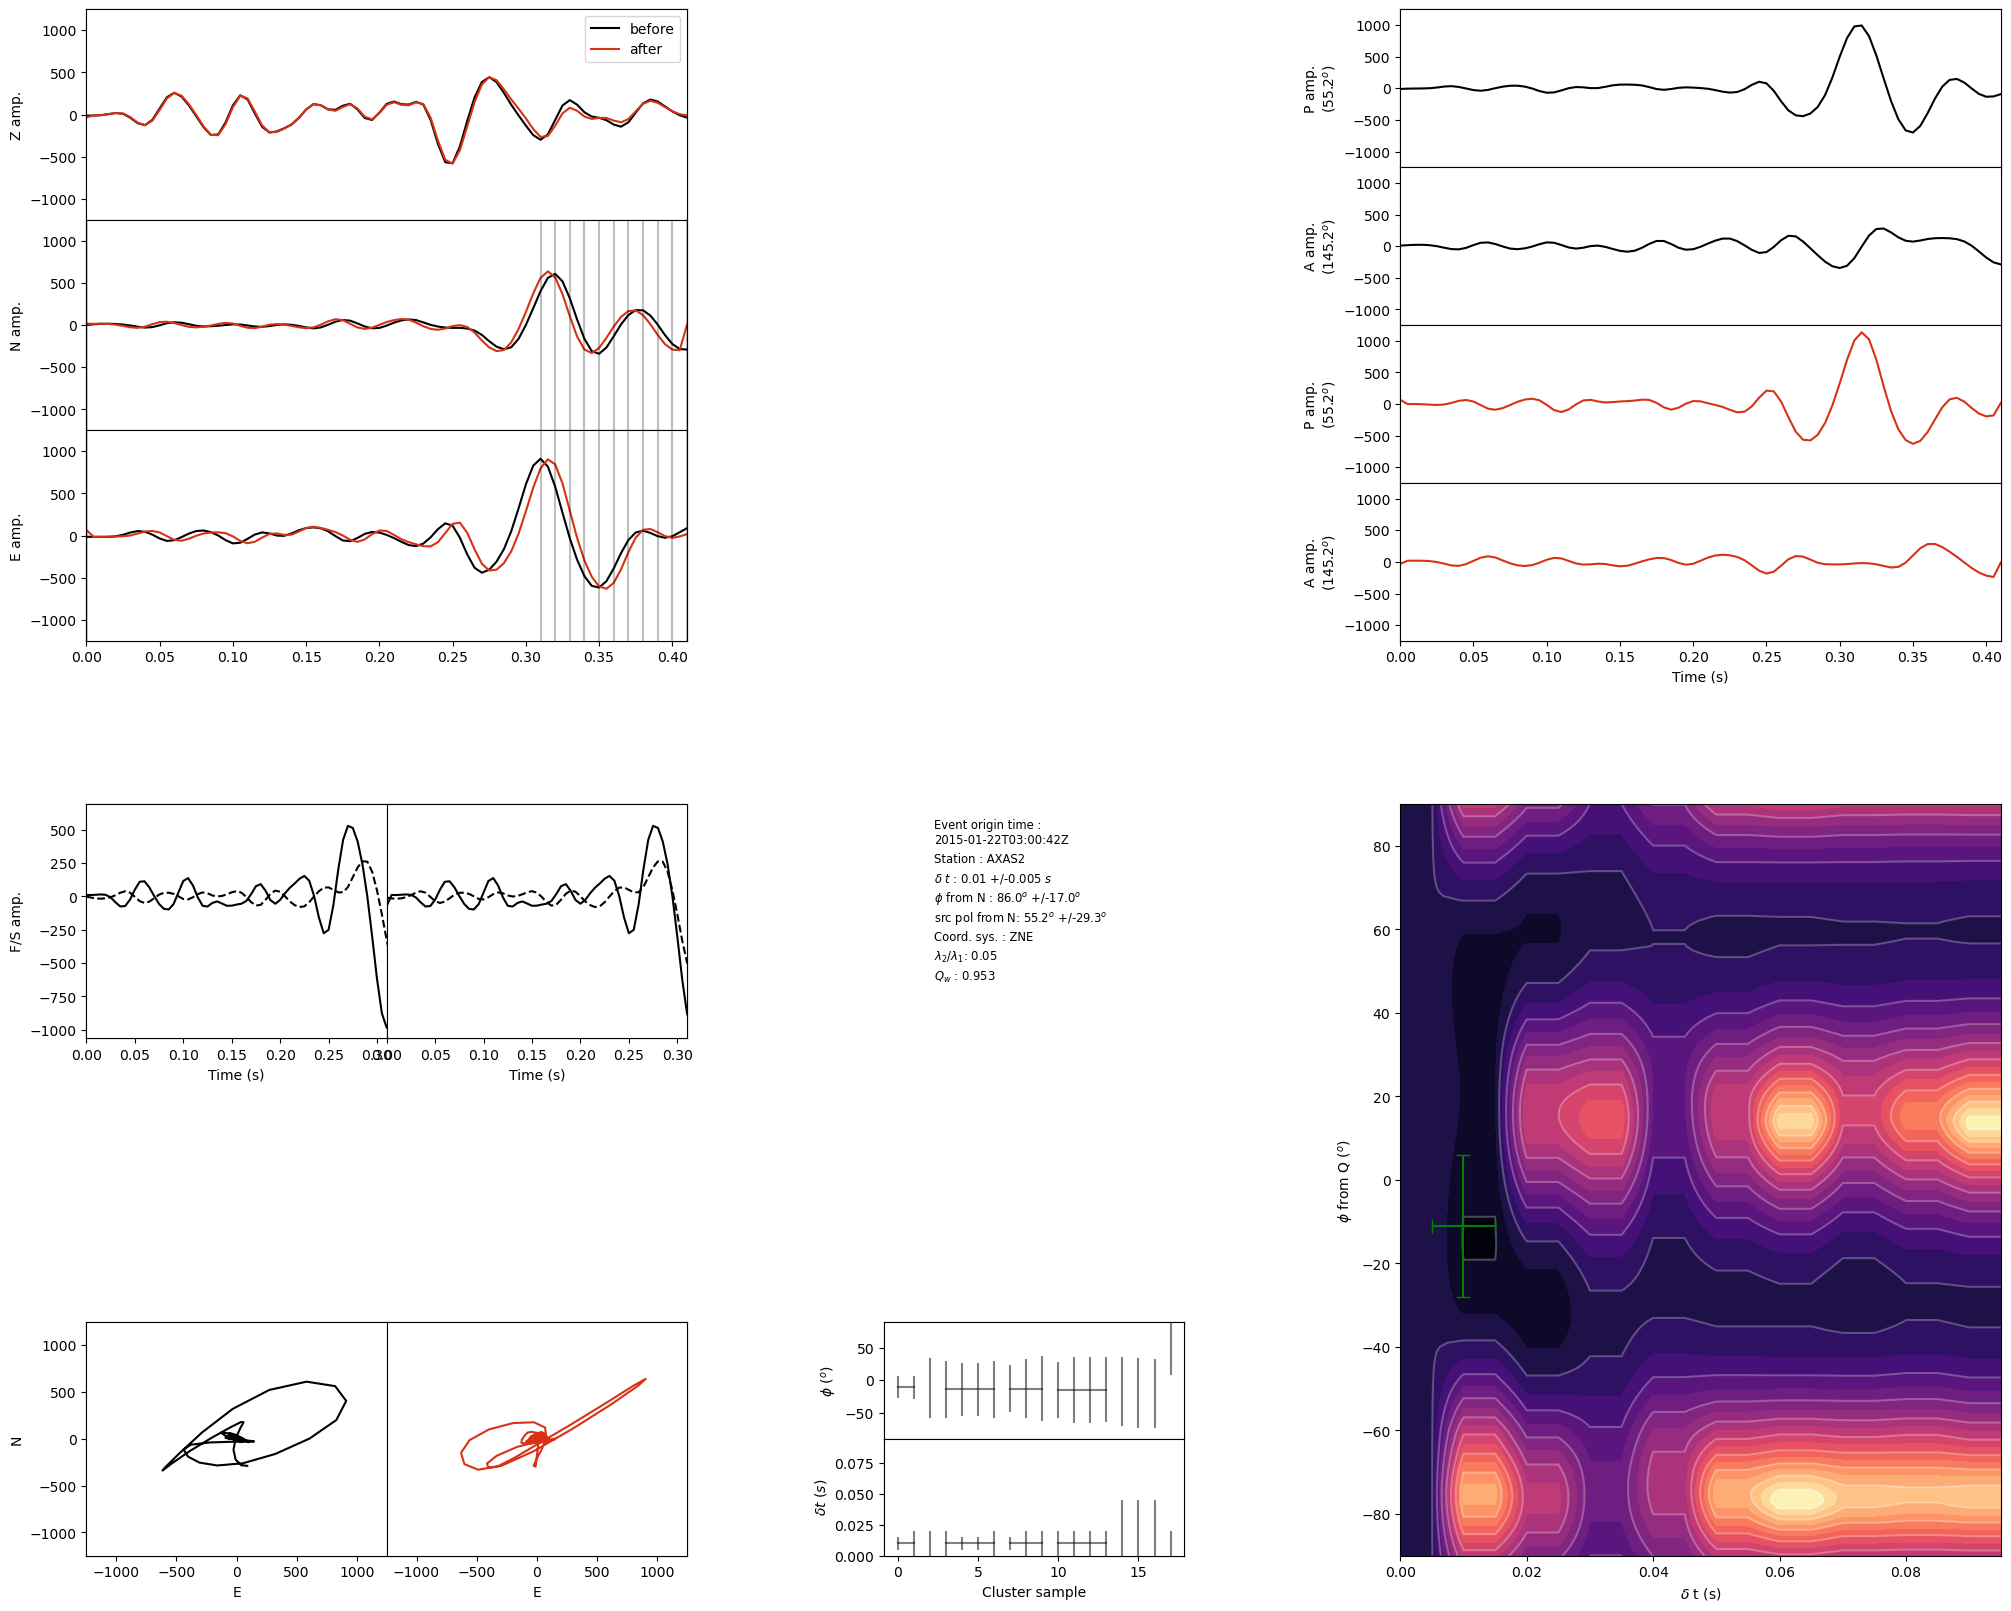

  ✓ Splitting analysis complete!
    Fast axis (φ): 86.0°
    Delay time (δt): 0.010s
  ✓ SUCCESS!
    Fast axis (φ): 86.0°
    Delay time (δt): 0.010s
    φ error: ±17.0°
    δt error: ±0.005s
    Dominant period: 0.100s

────────────────────────────────────────────────────────────
Event 82
────────────────────────────────────────────────────────────
  ✓ Found horizontal components
  ✓ Back-azimuth: 261.24°
  Station: AXAS2
  Magnitude: 0.0
  SNR: 5.37
  Rectilinearity: 0.837
  Incidence: 14.5°

  → Running splitting analysis with dynamic parameters...
  Creating SWSPy splitting object with dynamic parameters...
  Calculating dynamic parameters...
Error estimating dominant period: PPSD.__init__() missing 1 required positional argument: 'metadata'
Error estimating dominant period: PPSD.__init__() missing 1 required positional argument: 'metadata'
    Dominant period: 0.100 s
    Dynamic window length: 0.500 s
    Optimal frequency range: 5.0-25.0 Hz
  Applying bandpass filter: 5.0-25.0

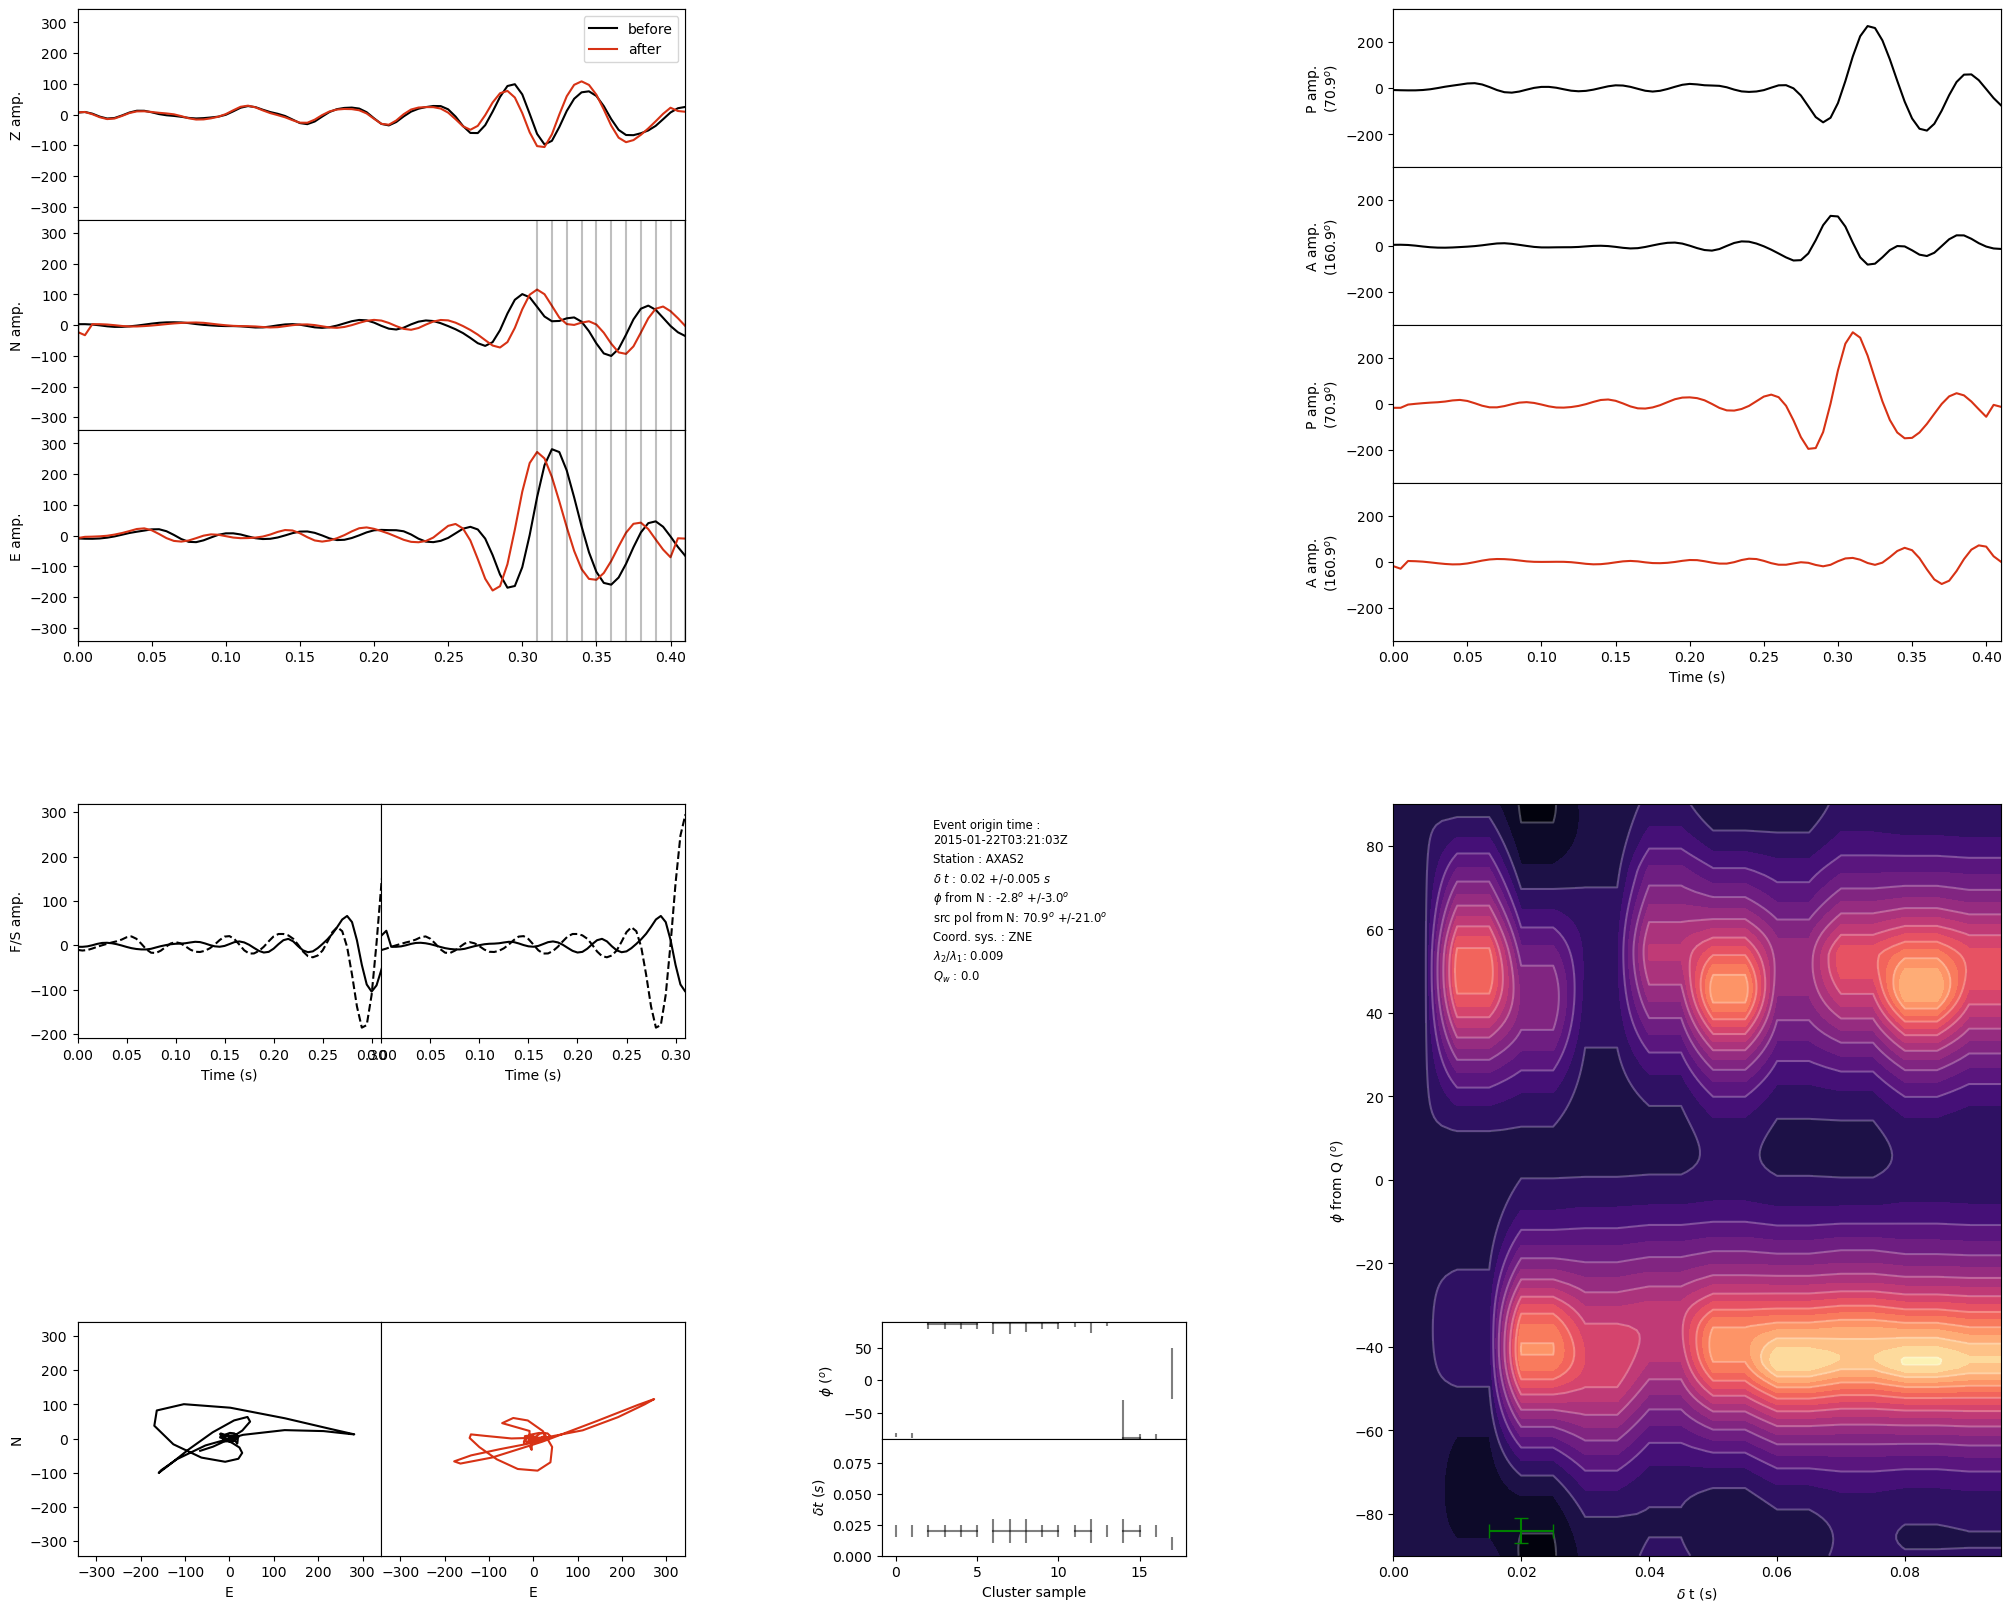

  ✓ Splitting analysis complete!
    Fast axis (φ): -2.8°
    Delay time (δt): 0.020s
  ✓ SUCCESS!
    Fast axis (φ): -2.8°
    Delay time (δt): 0.020s
    φ error: ±3.0°
    δt error: ±0.005s
    Dominant period: 0.100s

Splitting Analysis Summary
Total events processed: 2
Successful splits: 2 (100.0%)

Failure breakdown:
  Missing components: 0
  Missing back-azimuth: 0
  Splitting errors: 0

────────────────────────────────────────────────────────────
Splitting Parameter Statistics
────────────────────────────────────────────────────────────
Fast axis direction (φ):
  Mean: 41.6° ± 44.4°
  Range: -2.8° to 86.0°
  Median: 41.6°

Delay time (δt):
  Mean: 0.015 ± 0.005s
  Range: 0.010s to 0.020s
  Median: 0.015s


In [44]:
# Shear-wave splitting analysis using dynamic splitting parameters
print("Performing shear-wave splitting analysis using SWSPy...")
results = perform_splitting_on_organized_waveforms(passing_waveforms)

## 7. Visualization and Interpretation
- This section takes our results and makes a new dataframe of phi_from_N, phi_err, dt, dt_err, and datetime for each event.
- This section also plots fast direction (in +/- 0.2 radians) over time (+/- 24 hours 22:30 UTC April 23, 2015), with a colorbar representing confidence using phi_err (a 2D histogram), and in a second plot, lag time in seconds over the same time scales, also as a 2D histogram representing confidence

In [45]:
# Create results dataframe with splitting parameters
print("Creating results dataframe from splitting analysis...")

# Initialize lists to store results
event_ids = []
datetimes = []
phi_values = []
phi_errors = []
dt_values = []
dt_errors = []

# Extract results from the splitting analysis
for event_id, result_data in results.items():
    if 'result' in result_data and result_data['result'] is not None:
        result = result_data['result']
        
        # Get datetime from passing_waveforms
        if event_id in passing_waveforms:
            datetime_str = passing_waveforms[event_id]['datetime']
            
            event_ids.append(event_id)
            datetimes.append(datetime_str)
            phi_values.append(result.get('phi', np.nan))
            phi_errors.append(result.get('phi_error', np.nan))
            dt_values.append(result.get('dt', np.nan))
            dt_errors.append(result.get('dt_error', np.nan))

# Create dataframe
results_df = pd.DataFrame({
    'event_id': event_ids,
    'datetime': datetimes,
    'phi_from_N': phi_values,
    'phi_error': phi_errors,
    'dt': dt_values,
    'dt_error': dt_errors
})

# Convert datetime strings to datetime objects
results_df['datetime'] = pd.to_datetime(results_df['datetime'])

print(f"Created results dataframe with {len(results_df)} measurements")
print("\nSample results:")
display(results_df.head())

Creating results dataframe from splitting analysis...
Created results dataframe with 2 measurements

Sample results:


,event_id,datetime,phi_from_N,phi_error,dt,dt_error
0,67,2015-01-22 03:00:46.600000+00:00,86.000874,17.0,0.01,0.005
1,82,2015-01-22 03:21:07.700000+00:00,-2.757107,3.0,0.02,0.005


In [46]:
results

{67: {'result': {'station': 'AXAS2',
   'phi': 86.00087356492577,
   'dt': 0.01,
   'phi_error': 17.0,
   'dt_error': 0.005,
   'snr_avg': 4.019340666961858,
   's_arrival_time': 0.78,
   'magnitude': 0.0,
   'filter_freq_min': 5.0,
   'filter_freq_max': 25.0,
   'window_duration': 0.5,
   'success': True,
   'sws_result_df':   station  phi_from_Q  phi_from_N  phi_from_U  phi_err    dt  dt_err  \
   0   AXAS2       -11.0   86.000874   75.631249     17.0  0.01   0.005   
   
      src_pol_from_N  src_pol_from_U  src_pol_from_N_err  src_pol_from_U_err  \
   0       55.233655       97.569735           29.334993           99.196905   
   
          Q_w  lambda2/lambda1 ratio  ray_back_azi    ray_inc  
   0  0.95286               0.050471    277.000874  14.368751  ,
   'dynamic_params': {'t_dom': 0.1,
    't_dom_e': nan,
    't_dom_n': nan,
    'dynamic_window_length': 0.5,
    'optimal_freq_min': 5.0,
    'optimal_freq_max': 25.0,
    'center_frequency': 10.0},
   'dominant_period': 0.1,
 

In [56]:
# Probe into one specific event based on splitting results: is it a whale?
# Code 2015-01-22T03:10:01.000Z
# Event 1: 80
# Event 2: 314
event_id = 82

Selected event ID: {example_event_id}


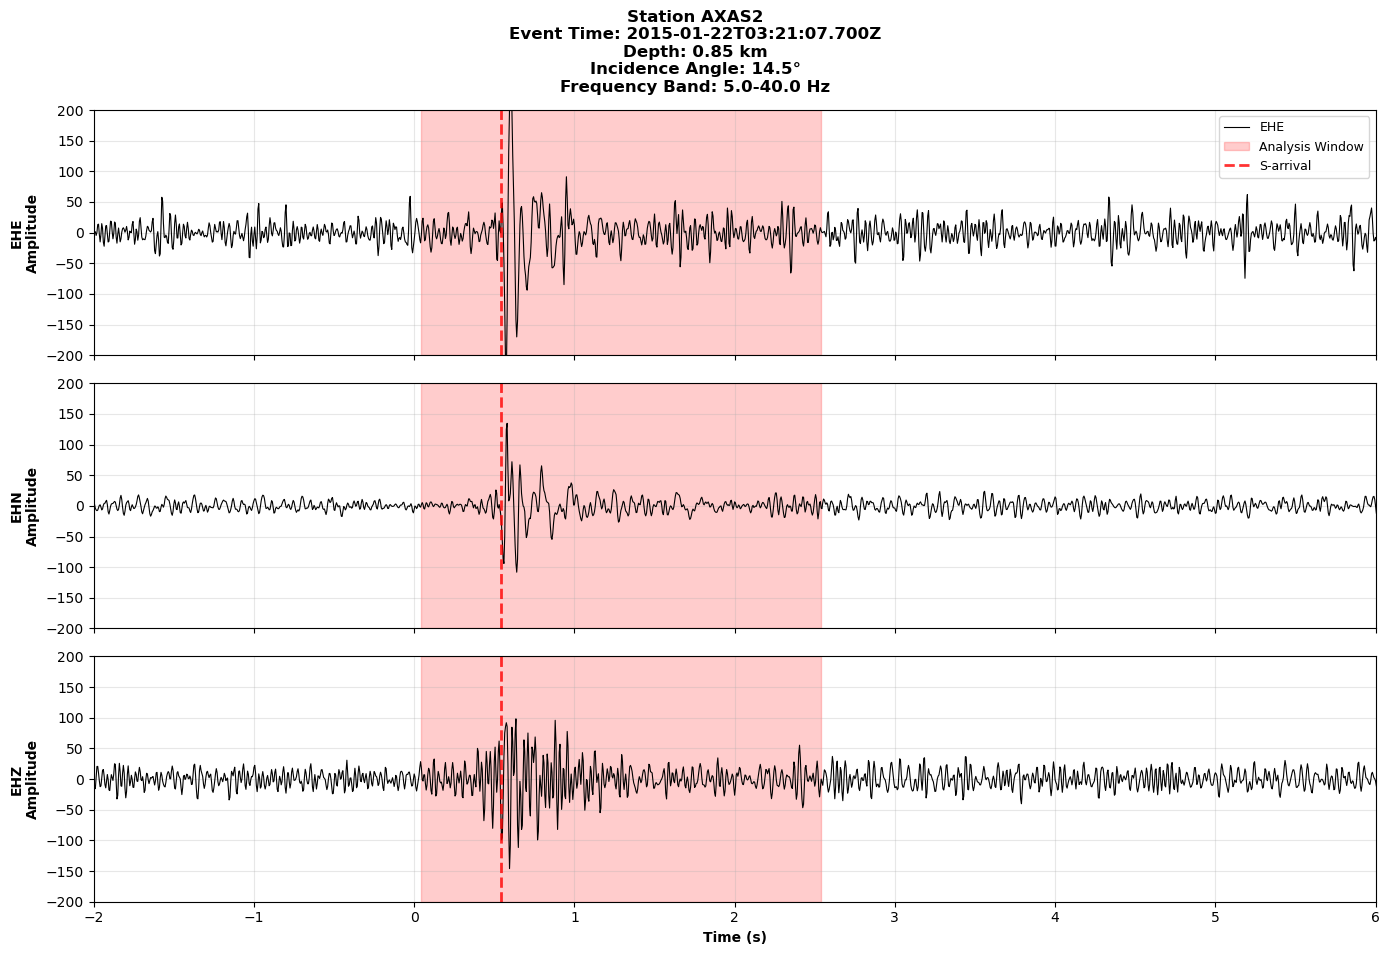

In [63]:


# Select an example from organized waveforms that passed quality control
example_data = passing_waveforms[event_id]

print("Selected event ID: {example_event_id}")

# Get the waveform traces
st = example_data['traces'].copy()

st = st.filter(type="bandpass", freqmin=5.0, freqmax= 40.0)
st = st.taper(type="hann", max_percentage=0.05)


# Plot the components
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Get S-wave arrival time relative to trace start
s_time_rel = example_data.get('s_arrival_time')

# Plot each component
for i, tr in enumerate(st.sort(['channel'])):
    ax = axes[i]
    
    # Filter for display
    trace_start = st[0].stats.starttime
    origin_time = UTCDateTime(example_data.get('origin_time'))
    time_offset = float(trace_start - origin_time)  # Should be -4.0 seconds
    time = tr.times() + time_offset  # Convert to origin-relative time
    
    # Plot waveform
    ax.plot(time, tr.data, 'k', linewidth=0.8, label=tr.stats.channel)
    ax.set_ylabel(f"{tr.stats.channel}\nAmplitude", fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # Highlight S-wave analysis window
    window_start = s_time_rel - 0.5
    window_end = s_time_rel + 2.0
    ax.axvspan(window_start, window_end, alpha=0.2, color='red', 
                label='Analysis Window' if i == 0 else '')
    
    # Add S-wave arrival marker
    ax.axvline(s_time_rel, color='red', linestyle='--', alpha=0.8, 
                linewidth=2, label='S-arrival' if i == 0 else '')
    
    # Set limits and formatting
    ax.set_xlim([-2, 6])
    ylim = np.max(np.abs(tr.data))
    ax.set_ylim(-200, 200)
    
    if i == 0:
        ax.legend(loc='upper right', fontsize=9)

axes[-1].set_xlabel('Time (s)', fontweight='bold')

# Title
title = (f"Station {example_data['station']}\n"
        f"Event Time: {example_data['datetime']}\n"
        f"Depth: {example_data['depth']:.2f} km\n"
        f"Incidence Angle: {example_data['incidence']:.1f}°\n"
        f"Frequency Band: 5.0-40.0 Hz")

fig.suptitle(title, fontsize=12, fontweight='bold', y=0.95)

plt.tight_layout()
plt.subplots_adjust(top=0.85)
plt.show()

print()

In [60]:
# Print out rectilinearity, SNR, and incidence angle for the selected event
print(f"Event: {example_data['station']} at {example_data['datetime']}")
print()
print("My results:")
print(f"Rectilinearity: {example_data['rectilinearity']:.3f}")
print(f"SNR: {example_data['snr_horizontal']:.2f}")
print(f"Incidence Angle: {example_data['incidence']:.1f}°")
print(f"S-pick Time: {(UTCDateTime(example_data['datetime']) + timedelta(seconds=example_data['s_arrival_time']))}")
print(f"Fast Direction: -0.3° from N")
print(f"Delay Time: 0.04s")
print()
print("Christian's results:")
print("Rectilinearity: 0.965")
print("SNR: 3.77")
print("Incidence Angle: 11.9°")
print("S-pick Time: 2015-01-22T10:15:32.750000Z")
print(f"Fast Direction: {np.rad2deg(0.73):.1f}° from N")



Event: AXAS2 at 2015-01-22T03:21:07.700Z

My results:
Rectilinearity: 0.837
SNR: 5.37
Incidence Angle: 14.5°
S-pick Time: 2015-01-22T03:21:08.240000Z
Fast Direction: -0.3° from N
Delay Time: 0.04s

Christian's results:
Rectilinearity: 0.965
SNR: 3.77
Incidence Angle: 11.9°
S-pick Time: 2015-01-22T10:15:32.750000Z
Fast Direction: 41.8° from N
